<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

## Data types

The module introduces specialized classes to represent various bioimaging data structures, facilitating seamless integration with machine learning workflows.

In [0]:
#| echo: false
#| output: asis
show_doc(MetaResolver)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/core.py#L47){target="_blank" style="float:right; font-size:smaller"}

### MetaResolver

```python

def MetaResolver(
    args:VAR_POSITIONAL, kwargs:VAR_KEYWORD
):


```

*The [`MetaResolver`](https://deepCLEM.github.io/bioMONAI/data.core.html#metaresolver) class addresses metaclass conflicts, ensuring compatibility across different data structures. This is particularly useful when integrating with libraries that have specific metaclass requirements.*

**BioImageBase** is a function that acts as a base class for biomedical images. It can be used for many things, such as loading image data as PyTorch tensors, displaying 2D slices of 3D images and making transformations on medical images. 

In [0]:
#| echo: false
#| output: asis
show_doc(BioImageBase)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/core.py#L79){target="_blank" style="float:right; font-size:smaller"}

### BioImageBase

```python

def BioImageBase(
    x, affine:torch.Tensor | None=None, meta:dict | None=None, applied_operations:list | None=None,
    _args:VAR_POSITIONAL, _kwargs:VAR_KEYWORD
)->None:


```

*Base class for bioimaging data.*

Provides:
- MetaTensor integration
- visualization utilities
- lightweight tensor wrapper

In [ ]:
a_dict = BioImageBase.create({'image': './data_examples/example_tiff.tiff'}, keys='image', channels="YX")
test_eq(type(a_dict), dict)
test_eq(type(a_dict['image']), BioImageBase)
a_dict

{'image': BioImageBase([[133, 133, 133,  ..., 133, 133, 132],
         [133, 133, 133,  ..., 133, 133, 133],
         [133, 133, 134,  ..., 133, 133, 133],
         ...,
         [133, 133, 133,  ..., 133, 133, 133],
         [133, 133, 133,  ..., 133, 133, 133],
         [133, 133, 134,  ..., 133, 132, 133]], dtype=torch.uint8)}

In [ ]:
a = BioImageBase.create('./data_examples/example_tiff.tiff', channels="YX")
test_eq(a.shape, a.meta['size_output'])
test_eq(a_dict['image'].meta.keys(), a.meta.keys())
a.meta

{256: 512,
 257: 512,
 258: 8,
 259: <COMPRESSION.NONE: 1>,
 262: <PHOTOMETRIC.MINISBLACK: 1>,
 273: (8,),
 274: <ORIENTATION.TOPLEFT: 1>,
 277: 1,
 278: 512,
 279: (262144,),
 284: <PLANARCONFIG.CONTIG: 1>,
 339: <SAMPLEFORMAT.UINT: 1>,
 affine: tensor([[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 1.]], dtype=torch.float64),
 space: RAS,
 'filepath': 'data_examples/example_tiff.tiff',
 'size_original': torch.Size([512, 512]),
 'transforms': {},
 'size_after_tfms': torch.Size([512, 512]),
 'format': 'TIFF',
 'layout': 'YX',
 'size_output': (512, 512),
 'width': 512,
 'height': 512,
 'channels': None,
 'depth': None,
 'frames': None,
 'sequence': None,
 spatial_shape: (512, 512),
 'mode': 'L',
 'kind': 'image',
 original_channel_dim: nan}

In [ ]:
a = BioImageBase.create('./data_examples/example_tiff.tiff')
print(a.shape)
print(type(a).__name__)
a.meta

torch.Size([1, 96, 512, 512])
BioImageBase


{256: 512,
 257: 512,
 258: 8,
 259: <COMPRESSION.NONE: 1>,
 262: <PHOTOMETRIC.MINISBLACK: 1>,
 273: (8,),
 274: <ORIENTATION.TOPLEFT: 1>,
 277: 1,
 278: 512,
 279: (262144,),
 284: <PLANARCONFIG.CONTIG: 1>,
 339: <SAMPLEFORMAT.UINT: 1>,
 affine: tensor([[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 1.]], dtype=torch.float64),
 space: RAS,
 'filepath': 'data_examples/example_tiff.tiff',
 'size_original': torch.Size([1, 96, 512, 512]),
 'transforms': {},
 'size_after_tfms': torch.Size([1, 96, 512, 512]),
 'format': 'TIFF',
 'layout': 'CZYX',
 'size_output': (1, 96, 512, 512),
 'width': 512,
 'height': 512,
 'channels': 1,
 'depth': 96,
 'frames': None,
 'sequence': None,
 spatial_shape: (96, 512, 512),
 'mode': 'L',
 'kind': 'volume',
 original_channel_dim: 0}

The load method returns a pure MetaTensor instead of a BioImageBase instance

In [ ]:
a = BioImageBase.load()('./data_examples/example_tiff.tiff') 
print(a.shape)
print(type(a).__name__)
a.meta

torch.Size([1, 96, 512, 512])
MetaTensor


{256: 512,
 257: 512,
 258: 8,
 259: <COMPRESSION.NONE: 1>,
 262: <PHOTOMETRIC.MINISBLACK: 1>,
 273: (8,),
 274: <ORIENTATION.TOPLEFT: 1>,
 277: 1,
 278: 512,
 279: (262144,),
 284: <PLANARCONFIG.CONTIG: 1>,
 339: <SAMPLEFORMAT.UINT: 1>,
 affine: tensor([[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 1.]], dtype=torch.float64),
 space: RAS,
 'filepath': 'data_examples/example_tiff.tiff',
 'size_original': torch.Size([1, 96, 512, 512]),
 'transforms': {},
 'size_after_tfms': torch.Size([1, 96, 512, 512]),
 'format': 'TIFF',
 'layout': 'CZYX',
 'size_output': (1, 96, 512, 512),
 'width': 512,
 'height': 512,
 'channels': 1,
 'depth': 96,
 'frames': None,
 'sequence': None,
 spatial_shape: (96, 512, 512),
 'mode': 'L',
 'kind': 'volume',
 original_channel_dim: 0}

In [ ]:
a = BioImageBase.load_dict(keys=['image'])({'image': './data_examples/example_tiff.tiff'}) 
print(a['image'].shape)
print(type(a).__name__)
a['image'].meta

torch.Size([1, 96, 512, 512])
dict


{256: 512,
 257: 512,
 258: 8,
 259: <COMPRESSION.NONE: 1>,
 262: <PHOTOMETRIC.MINISBLACK: 1>,
 273: (8,),
 274: <ORIENTATION.TOPLEFT: 1>,
 277: 1,
 278: 512,
 279: (262144,),
 284: <PLANARCONFIG.CONTIG: 1>,
 339: <SAMPLEFORMAT.UINT: 1>,
 affine: tensor([[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 1.]], dtype=torch.float64),
 space: RAS,
 'filepath': 'data_examples/example_tiff.tiff',
 'size_original': torch.Size([1, 96, 512, 512]),
 'transforms': {},
 'size_after_tfms': None,
 'format': 'TIFF',
 'layout': 'CZYX',
 'size_output': (1, 96, 512, 512),
 'width': 512,
 'height': 512,
 'channels': 1,
 'depth': 96,
 'frames': None,
 'sequence': None,
 spatial_shape: (96, 512, 512),
 'mode': 'L',
 'kind': 'volume',
 original_channel_dim: 0}

It is possible to load only an ROI, which should be indicated by using an index dictionary.

BioImageBase
torch.Size([1, 300, 512])


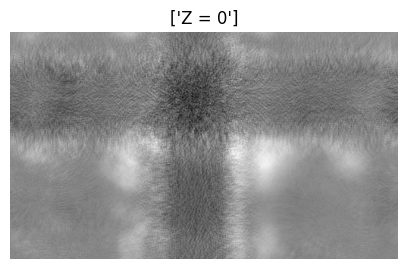

In [ ]:
imagebase_2d = BioImageBase.create('./data_examples/example_tiff.tiff', channels="CYX", ind_dict={'Z': 0, 'Y': slice(0, 300)})  
print((type(imagebase_2d)).__name__) 
print(imagebase_2d.shape)
imagebase_2d.show(title="Z = 0", figsize=(5, 5));

BioImageBase
torch.Size([10, 300, 512])


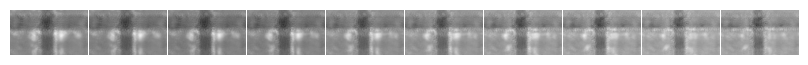

In [ ]:
imagebase_3d = BioImageBase.create('./data_examples/example_tiff.tiff', channels="ZYX", ind_dict={'Z': range(10), 'Y': slice(0, 300)})  
print((type(imagebase_3d)).__name__) 
print(imagebase_3d.shape)
imagebase_3d.show();

**BioImage** is a specialization of BioImageBase that is specifically used for 2D and 3D biomedical images. To do so, it directly inherits from that class and then squeezes the image data and allows for transformations to be made there.

In [0]:
#| echo: false
#| output: asis
show_doc(BioImage)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/core.py#L175){target="_blank" style="float:right; font-size:smaller"}

### BioImage

```python

def BioImage(
    x, affine:torch.Tensor | None=None, meta:dict | None=None, applied_operations:list | None=None,
    _args:VAR_POSITIONAL, _kwargs:VAR_KEYWORD
)->None:


```

*Tensor-backed bioimage loaded from disk.*

BioImage


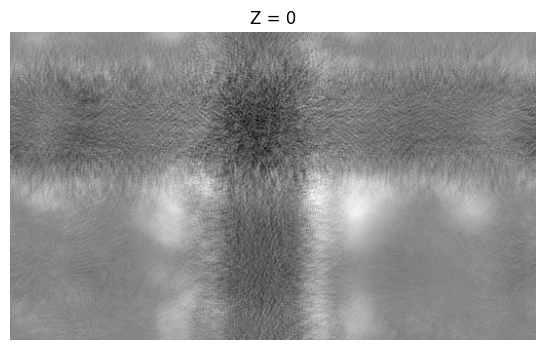

In [ ]:
image_2d = BioImage.create('./data_examples/example_tiff.tiff', ind_dict={'Z': 0, 'Y': slice(0, 300)}) 
print((type(image_2d)).__name__) 
test_eq(imagebase_2d, image_2d)
image_2d.show(title="Z = 0");

In [ ]:
image_2d = BioImage.load(ind_dict={'Z': 0, 'Y': slice(0, 300)})('./data_examples/example_tiff.tiff')  
print((type(image_2d)).__name__)
test_eq(imagebase_2d, image_2d)

MetaTensor


In [0]:
#| echo: false
#| output: asis
show_doc(BioVolume)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/core.py#L206){target="_blank" style="float:right; font-size:smaller"}

### BioVolume

```python

def BioVolume(
    x, affine:torch.Tensor | None=None, meta:dict | None=None, applied_operations:list | None=None,
    _args:VAR_POSITIONAL, _kwargs:VAR_KEYWORD
)->None:


```

*Tensor-backed bioimage loaded from disk.*

This is the class that:
- uses image_reader
- handles transforms
- returns MetaTensor-backed images

BioVolume
torch.Size([1, 10, 300, 512])


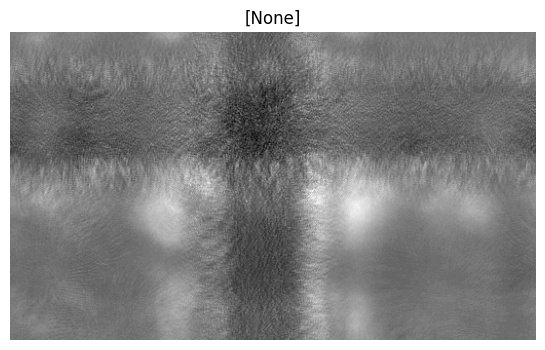

In [ ]:
image_3d = BioVolume.create('./data_examples/example_tiff.tiff', ind_dict={'Z': range(10), 'Y': slice(0, 300)})  
print((type(image_3d)).__name__)
print(image_3d.shape)
test_eq(imagebase_3d, image_3d[0])
image_3d.show();

In [ ]:
image_3d = BioVolume.load(ind_dict={'Z': range(10), 'Y': slice(0, 300)}, channels="ZYX")('./data_examples/example_tiff.tiff')  
print(image_3d.shape)
test_eq(imagebase_3d, image_3d)

torch.Size([10, 300, 512])


torch.Size([1, 512, 512])


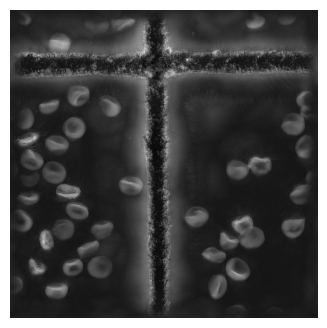

In [ ]:
image_mip = BioMIP.create('./data_examples/example_tiff.tiff')  
print(image_mip.shape)
# test_eq(imagebase_mip, image_mip)
image_mip.show();

In [ ]:
image_mip.meta

{256: 512,
 257: 512,
 258: 8,
 259: <COMPRESSION.NONE: 1>,
 262: <PHOTOMETRIC.MINISBLACK: 1>,
 273: (8,),
 274: <ORIENTATION.TOPLEFT: 1>,
 277: 1,
 278: 512,
 279: (262144,),
 284: <PLANARCONFIG.CONTIG: 1>,
 339: <SAMPLEFORMAT.UINT: 1>,
 affine: tensor([[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 1.]], dtype=torch.float64),
 space: RAS,
 'filepath': 'data_examples/example_tiff.tiff',
 'size_original': torch.Size([1, 96, 512, 512]),
 'transforms': {},
 'size_after_tfms': torch.Size([1, 96, 512, 512]),
 'format': 'TIFF',
 'layout': 'CYX',
 'size_output': (1, 512, 512),
 'width': 512,
 'height': 512,
 'channels': 1,
 'depth': 96,
 'frames': None,
 'sequence': None,
 spatial_shape: (96, 512, 512),
 'mode': 'L',
 'kind': 'volume',
 original_channel_dim: 0}

In [0]:
#| echo: false
#| output: asis
show_doc(BioVideo)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/core.py#L289){target="_blank" style="float:right; font-size:smaller"}

### BioVideo

```python

def BioVideo(
    x, affine:torch.Tensor | None=None, meta:dict | None=None, applied_operations:list | None=None,
    _args:VAR_POSITIONAL, _kwargs:VAR_KEYWORD
)->None:


```

*Tensor-backed video loaded from disk.*

This is the class that:
- uses image_reader
- handles transforms
- returns MetaTensor-backed images

In [0]:
#| echo: false
#| output: asis
show_doc(BioMultiChannel)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/core.py#L329){target="_blank" style="float:right; font-size:smaller"}

### BioMultiChannel

```python

def BioMultiChannel(
    x, affine:torch.Tensor | None=None, meta:dict | None=None, applied_operations:list | None=None,
    _args:VAR_POSITIONAL, _kwargs:VAR_KEYWORD
)->None:


```

*Multi-channel 2D/3D image assuming CZYX layout.*

Layout: CYX


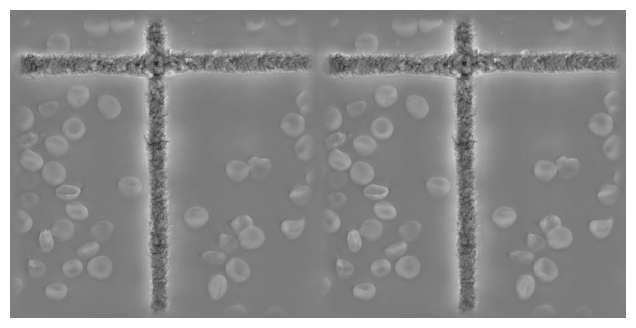

In [ ]:
image_mlt = BioMultiChannel.create('./data_examples/example_tiff.tiff')  
test_eq(image_mlt.shape, [96, 512, 512])
image_mlt.show();
print('Layout:', image_mlt.meta['layout'])

## Data conversion

To facilitate seamless integration between tensors and bioimaging data structures, the module provides conversion utilities.

In [0]:
#| echo: false
#| output: asis
show_doc(Tensor2BioImage)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/core.py#L388){target="_blank" style="float:right; font-size:smaller"}

### Tensor2BioImage

```python

def Tensor2BioImage(
    cls:BioImageBase=BioImage
):


```

*The [`Tensor2BioImage`](https://deepCLEM.github.io/bioMONAI/data.core.html#tensor2bioimage) transform converts tensors into [`BioImageBase`](https://deepCLEM.github.io/bioMONAI/data.core.html#bioimagebase) instances, enabling the application of bioimaging-specific methods to tensor data. *
This is essential for integrating deep learning models with bioimaging workflows.